## Linker Analysis of Nanopore Amplicon Sequencing Data

This notebook analyzes **Nanopore long-read amplicon** sequencing datasets, which have undergone preprocessing, alignment, and frame correction.

Please make sure to download the input dataset `Nanopore` from the Zenodo repository and place it in a folder named `data` at root repository level.

Before using this notebook for sequence analysis, ensure that the preprocessing script `00_Nanopore_filtering_alignment_processing.sh` has been run. This script performs:

1. Quality filtering of Nanopore reads (`01_Nanopore_read_filtering.py`)
2. Alignment to the reference sequence (`02_Nanopore_alignment.py`)
3. Correction of indel errors typical of Nanopore sequencing, including frame enforcement to enable codon-level mutation analysis (`03_Nanopore_quality_control.py`)

Alternatively, you may run the scripts in the brackets in the given order to achieve the same result.

For more details, see the `README.md` file in this repository.


---

#### This notebook includes the following steps:
- Calculation of mutation enrichment based on aligned Nanopore reads
- Extraction of enrichment data within the defined AraC-LOV2 region of interest
- Quantification and visualization of insertion and deletion (indel) frequencies across the reference sequence
- Export of enrichment metrics (absolute, relative, and variant-level) for downstream analysis
---


## Notebook Setup
----------------------------

Run the following cell to import all required libraries, define plotting settings, and configure the environment for data analysis and visualization.

In [1]:
# --- Import necessary modules ---
import os
import sys
import json
import ast
import csv
import gzip
import pickle as pkl
from importlib import reload
from pathlib import Path

notebook_dir = Path().resolve()
repo_root = notebook_dir.parent.parent 
sys.path.append(str(repo_root))

import numpy as np
import pandas as pd
from scipy import stats
import scipy
from Bio import SeqIO
from Bio.SeqIO import QualityIO
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib import patches
from matplotlib import cm
from matplotlib import colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import pysam
from scripts.utils import dna_rev_comp, translate_dna2aa
from scripts.linker_analysis_functions import *
from scripts.preprocessing_functions import *
from scripts.plotting import *
from scripts.functions_ import *
from scripts.Nanopore_functions import *

# ======================== PLOTTING SETTINGS ========================

# --- Custom color map for mutation visualization ---
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", [
    "#22577A",  # Deep blue
    "#38A3A5",  # Teal
    "#57CC99",  # Medium green
    "#80ED99",  # Bright green
    "#C7F9CC"   # Light pastel green
], N=256)

# --- Seaborn theme configuration ---
custom_params = {
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 1
}
sns.set_theme(context="paper", style='ticks', palette="Greys_r", rc=custom_params)

# --- General matplotlib settings ---
fs = 8  # font size
plt.rcParams['svg.fonttype'] = 'none'
mpl.rcParams.update({
    'font.family': 'Avenir Next',
    'font.weight': 'demi', 
    'font.size': fs,
    'text.color': '#231F20',
    'axes.labelcolor': '#231F20',
    'xtick.color': '#231F20',
    'ytick.color': '#231F20',
    'axes.edgecolor': '#231F20',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'pdf.fonttype': 42,
    'text.usetex': False
})
sns.set_context("paper", rc={
    "font.size": fs,
    "axes.titlesize": fs + 1,
    "axes.labelsize": fs,
    "axes.linewidth": 1,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs,
    "legend.title_fontsize": fs + 1
})

avenir_fp = FontProperties(family='Avenir Next', weight='demi', size=fs)

# ======================== LAYOUT PARAMETERS ========================

# --- Pre-defined figure dimensions for multi-panel plots ---
hi = 10.5 * 0.75
wi3 = 2.24
wi2 = 4.76
wi1 = 7.24
nr = 5

# --- Utility for shortening sample names ---
short_fn = np.vectorize(lambda x: x[:5])

/Users/alicehovsepyan/opt/miniconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# ======================== ANALYSIS PARAMETERS ========================

ref_R2 = "taatggaaacttcctcatgaaaaagtctttagtcctcaaagcctctgtagccgttgctaccctcgttccgatgctgtctttcgctgctgagggtgacgatcccgcaaaagcggcctttgactccctgcaagcctcagcgaccgaatatatcggttatgcgtgggcgatggttgttgtcattgtcggcgcaactatcggtatcaagctgtttaagaaattcacctcgaaagcaagttgataaactgatacaattaaaggctccttttggagcctttttttttggagtaaggaggaaaaAtgtccgcgAaagcgcagaacgatccgctgctgccgggctatagctttaacgcAcatctggtggcgggcctgaccccgattgaagcgaacggctatctggatttttttattgatcgcccgctgggcatgaaaggctatattctgaacctgaccattcgcggccagggcgtggtgaaaaaccagggccgcgaatttgtgtgccgcccgggcgatattctgctgtttccgccgggcgaaattcatcattatggccgccatccggaagcgcgAgaatggtatcatcagtgggtgtattttcgcccgcgcgcgtattggcatgaatggctgaactggccgagcatttttgcgaacaccggcttttttcgcccggatgaagcgcatcagccgcattttagcgatctgtttggccagattattaacgcgggccagggcgaaggccTctatagcgaactgctgAcAattaacctgctggaacagctgctgctgcgccgCATGGAAGCGATTAACGAAAGCagcggtttagccacaacgctggaacgcattgaaaagaatttcgtaatcacagacccgcgccttcccgacaatccaattatttttgcgtccgatagcttcctgcaattaaccgaatacagccgcgaagaaattctgggtcgtaattgtcgcttccttcaggggccagagactgaccgtgctacggtacgcaaaatccgcgacgcaatcgacaatcaaacggaagtcacggttcagttgattaactatacgaagagcggaaaaaaattctggaatttatttcacttgcagcctatgcgtgaccagaagggcgatgtccagtatttcattggcgttcagcttgatggtaccgagcatgttcgcgatgctgcggagcgtgaaggtgtaatgttaattaaaaagactgctgaaaacattgatgaggcggccaaagggagcCTGCATCCGCCGATGGATAACCGcgtgcgcgaagcgtgccagtatattagcgatcatctggcggatagcaactttgatattgcgagcgtggcgcagcatgtgtgcctgagcccTagccgcctgagccatctgtttcgccagcagctgggcattagcgtgctgagctggcgcgaagatcagcgcattagccaggcgaaactgctgctgagcaccacccgcatgccgattgcgaccgtgggccTcaacgtgggctttgatgatcagctgtattttagccgcgtgtttaaaaaatgcaccggcgcgagcccgagcgaatttcgcgcgggctgcgaagaaaaagtGAACGATGTGGCGGTGAAACTGAGCGGGTAAggctaatggagattttcaacatgggctagcacagccctaggtattatgctagcgtggtgtctgcgtaataaggagtcttaatcatgccagttcttttgggtattccgttattattgcgtttcctcggtttccttctggtaactttgttcggctatctgcttacttttctcaaaaagggcttcggtaagatagctattgctatttcattgtttcttgctcttattattgggcttaactcaattcttgtgggttatctctctgatattagtgctcaattaccctctgactttgttcagggtgttcagttaattctcccgtctaatgcgcttccctgtttttatgttattctctctgt".upper() ## R2

cut_site_seq_left= "gccacaa".upper()
cut_site_seq_right= "tgctgaaaac".upper()

wt_linker_left = "INESSGL" 
wt_linker_right = "IDEAAKGSHLPP"

quality = 20
data_folder = 'Nanopore/Nanopore_P0115'

### Analysis and Renaming of Linker Variants Across Barcodes

In this step, we analyze the distribution and co-occurrence of linker variants across all barcodes, including standard bar plots for visualizing variant frequencies.
Linker names are renamed using the `linker_renaming.txt` file. Please verify that the renaming was applied correctly, as rare or unexpected mutations may interfere with the renaming process.

In [ ]:
# --- Loop over barcodes ---
barcodes = ['R2-LOV_RAMPhaGE_Linker_Mut_D1', 'R2-LOV_P1_Neg_D2', 'R2-LOV_P2_Neg_D2', 'R2-LOV_P1_Pos_D3', 'R2-LOV_P2_Pos_D3', 'R2-LOV_P1_Pos_D4', 'R2-LOV_P2_Pos_D\4']
for barcode in barcodes:
    # --- Define input and output folders ---
    input_folder = f"{repo_root}/data/{data_folder}/{barcode}/highly_accurate_basecalling/filtered_Q{quality}_maxminlen/"
    FigFolder = f"{repo_root}/final_output/{data_folder}/{barcode}/"
    if not os.path.exists(FigFolder):
        os.makedirs(FigFolder)

    # --- Extract left and right linker regions from aligned reads ---
    all_left_linkers, all_right_linkers = get_linker_regions(input_folder= input_folder+ "minimap2_alignment", ref = ref_R2, cut_site_seq_left=cut_site_seq_left, cut_site_seq_right= cut_site_seq_right, left_linker_region_len= 12*3, right_linker_region_len= 20*3)


    ######### LEFT LINKER ANALYSIS #########
    read_dir = "R1"
    # --- Count linker variants and extract list of raw alignments ---
    left_linkers_counts, left_linker_list = get_linker_variants(linker_alignments=all_left_linkers,  wt_linker = wt_linker_left if read_dir=="R1" else wt_linker_right, read_dir = read_dir)

    # --- Sort variants by frequency ---
    linkers_sorted = {k: v for k, v in sorted(left_linkers_counts.items(), key=lambda item: item[1], reverse=True)}
    total_reads = sum(linkers_sorted.values())
    linkers_sorted_perc = {k: v/total_reads*100 for k, v in linkers_sorted.items()}

    # --- Remove wild-type and variants with less than 10% frequency ---
    linkers_sorted_perc.pop("wt")
    linkers_perc_filt, left_linker_renaming = rename_left_linkers(linkers_sorted_perc.keys(), linkers_sorted_perc)
    linkers_perc_filt = {k: v for k, v in linkers_perc_filt.items() if v > 0.1}


    # --- Plot left linker variant distribution ---
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))
    plt.bar(linkers_perc_filt.keys(), linkers_perc_filt.values(), color ="#22577A")
    plt.xticks(rotation=90)
    plt.ylabel("Percentage of reads")
    plt.text(0.9, 0.93, f"Total mutation rate: {round(sum(linkers_perc_filt.values()),3)}", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    plt.title(f"Linker variants for {barcode} {read_dir}")
    # plt.savefig(f"{FigFolder}/linker_distribution_{read_dir}.pdf", bbox_inches="tight")
    # plt.savefig(f"{FigFolder}/linker_distribution_{read_dir}.png", bbox_inches="tight")
    plt.close()

    # --- Save left linker variant frequencies to CSV ---
    linkers_perc_filt = pd.DataFrame.from_dict(linkers_perc_filt, orient="index")
    linkers_perc_filt.to_csv(f"{FigFolder}/linker_distribution_{read_dir}.csv")


    ######### RIGHT LINKER ANALYSIS #########
    read_dir = "R2"
    # --- Count right linker variants and extract list ---
    right_linkers_counts, right_linkers_list = get_linker_variants(linker_alignments=all_right_linkers, wt_linker = wt_linker_left if read_dir=="R1" else wt_linker_right, read_dir = read_dir)

    # --- Sort and filter right linker variants ---
    linkers_sorted = {k: v for k, v in sorted(right_linkers_counts.items(), key=lambda item: item[1], reverse=True)}
    total_reads = sum(linkers_sorted.values())
    linkers_sorted_perc = {k: v/total_reads*100 for k, v in linkers_sorted.items()}
    # --- Remove wild-type and variants with less than 10% frequency ---
    linkers_sorted_perc.pop("wt")
    linkers_perc_filt, right_linker_renaming = rename_right_linkers(linkers_sorted_perc.keys(), linkers_sorted_perc)
    linkers_perc_filt = {k: v for k, v in linkers_perc_filt.items() if v > 0.1}

    # --- Plot right linker variant distribution ---
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))
    plt.bar(linkers_perc_filt.keys(), linkers_perc_filt.values(), color ="#22577A")
    plt.xticks(rotation=90)
    plt.ylabel("Percentage of reads")
    plt.text(0.9, 0.93, f"Total mutation rate: {round(sum(linkers_perc_filt.values()),3)}", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    plt.title(f"Linker variants for {barcode} {read_dir}")
    # plt.savefig(f"{FigFolder}/linker_distribution_{read_dir}.pdf", bbox_inches="tight")
    # plt.savefig(f"{FigFolder}/linker_distribution_{read_dir}.png", bbox_inches="tight")
    plt.close()

    # --- Save right linker variant frequencies to CSV ---
    linkers_perc_filt = pd.DataFrame.from_dict(linkers_perc_filt, orient="index")
    linkers_perc_filt.to_csv(f"{FigFolder}/linker_distribution_{read_dir}.csv")


    ######### COOCCURRENCE ANALYSIS #########
    cooccurrences = []
    for idx, right_linker in enumerate(right_linkers_list): 
        if right_linker == "": 
            continue
        left_linker = left_linker_list[idx] 
        right_linker_renamed = right_linker_renaming[right_linker] if right_linker != "wt" else "wt"
        left_linker_renamed = left_linker_renaming[left_linker] if left_linker != "wt" else "wt"

        cooccurrences.append(f"{left_linker_renamed}_{right_linker_renamed}")
    
    # --- Save cooccurrence combinations to file ---
    with open(f"{FigFolder}/cooccurrences.txt", "w") as f: 
        f.write("\n".join(cooccurrences))
    
    # --- Save linker renaming dictionaries as JSON ---
    with open(f"{FigFolder}/linker_renaming_left_linker.json", "w") as f:
        json.dump(left_linker_renaming, f, indent=4)
    
    with open(f"{FigFolder}/linker_renaming_right_linker.json", "w") as f:
        json.dump(right_linker_renaming, f, indent=4)
    
    # --- Save raw linker alignment data to JSON ---
    if not os.path.exists(f"{input_folder}/processed_reads"):
        os.makedirs(f"{input_folder}/processed_reads")
        
    with open(f"{input_folder}/processed_reads/all_left_linkers.json", "w") as f:
        json.dump(all_left_linkers, f, indent=4)
    
    with open(f"{input_folder}/processed_reads/all_right_linkers.json", "w") as f:
        json.dump(all_right_linkers, f, indent=4)
        
    print("Barcode", barcode, "done")   


Status: 1 / 158 done
Processed fastq_runid_1375da9897689a251ba506449c1d303f48c780f1_98_0.bam
Status: 2 / 158 done
Processed fastq_runid_1375da9897689a251ba506449c1d303f48c780f1_21_0.bam
Status: 3 / 158 done
Processed fastq_runid_1375da9897689a251ba506449c1d303f48c780f1_0_0.bam
Status: 4 / 158 done
Processed fastq_runid_1375da9897689a251ba506449c1d303f48c780f1_33_1.bam
Status: 5 / 158 done
Processed fastq_runid_1375da9897689a251ba506449c1d303f48c780f1_96_1.bam
Status: 6 / 158 done
Processed fastq_runid_1375da9897689a251ba506449c1d303f48c780f1_59_1.bam
Status: 7 / 158 done


KeyboardInterrupt: 

### Linker evolution analysis: What's below is also included in figure notebooks, so will probably remove from here as well

In [ ]:
# --- Load previously generated linker variant distributions from multiple barcodes ---

all_left_linkers = pd.DataFrame(dtype = float)
all_right_linkers = pd.DataFrame(dtype = float)
all_linker_vars = []

# --- Specify which barcodes to include ---
barcodes =  [13, 16, 19, 21]
barcodes = [str(bc) for bc in barcodes]

# --- Loop through each barcode to load R1 and R2 linker data ---
for barcode in barcodes: 
    FigFolder = f"final_output/{data_folder}/barcode{barcode}/"
    # --- Load and append left linker (R1) data ---
    left_linkers = pd.read_csv(f"{FigFolder}/linker_distribution_R1.csv", index_col = 0).T
    left_linkers.index = [str(barcode)]
    all_left_linkers = pd.concat([all_left_linkers, left_linkers], axis = 0)
    # --- Load and append right linker (R2) data ---
    right_linkers = pd.read_csv(f"{FigFolder}/linker_distribution_R2.csv", index_col = 0).T
    all_right_linkers = pd.concat([all_right_linkers, right_linkers], axis = 0)

# --- Ensure index consistency and fill missing values with 0 ---
all_right_linkers.index = [str(bc) for bc in barcodes]
all_left_linkers.index = [str(bc) for bc in barcodes]

all_right_linkers.fillna(0, inplace = True)
all_left_linkers.fillna(0, inplace = True)

# --- Convert percentages to mutation rates (i.e., fraction of reads) ---
all_right_linkers = all_right_linkers/100
all_left_linkers = all_left_linkers/100


# ======================== GENERATE HEATMAPS OF LINKER MUTATION FREQUENCIES ========================

# --- Select top n linker variants with highest variance across barcodes ---
n_linkers = 10 

# --- Calculate variance for each left linker variant ---
left_vars = all_left_linkers.var()
left_quant = n_linkers/all_left_linkers.shape[1]
left_quantile_threshold = np.percentile(left_vars, 100-left_quant*100)

# --- Select left linkers with variance above threshold ---
left_top_indices = [i for i, var in enumerate(left_vars) if var >= left_quantile_threshold]
left_top_vars = all_left_linkers.iloc[:,left_top_indices]

# --- Calculate variance for each right linker variant ---
right_vars = all_right_linkers.var()
right_quant = n_linkers/all_right_linkers.shape[1]
right_quantile_threshold = np.percentile(right_vars, 100-right_quant*100)

# --- Select right linkers with variance above threshold ---
right_top_indices = [i for i, var in enumerate(right_vars) if var >= right_quantile_threshold]
right_top_vars = all_right_linkers.iloc[:,right_top_indices]

# --- Sort variants by abundance on the last barcode (representing the final enrichment day) ---
right_top_vars = right_top_vars.sort_values(right_top_vars.last_valid_index(), axis=1,ascending=False)
left_top_vars = left_top_vars.sort_values(left_top_vars.last_valid_index(), axis=1,ascending=False)

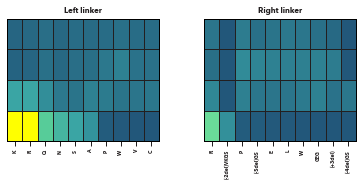

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(6.25, 2.25))  # 1 row, 2 columns
fig.subplots_adjust(wspace=0.3)  # horizontal spacing

my_cmap = custom_cmap
my_cmap.set_over('Yellow')

# Left heatmap (Left linker)
sns.heatmap(left_top_vars, cmap=my_cmap, vmax=0.10, ax=ax[0], cbar=False,
            yticklabels=False, xticklabels=True, linecolor="#231F20", linewidths=1)
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].set_title("Left linker")
for label in ax[0].get_xticklabels():
    label.set_fontsize(5)
for spine in ax[0].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

# Right heatmap (Right linker)
sns.heatmap(right_top_vars, cmap=my_cmap, vmax=0.10, ax=ax[1], cbar=False,
            yticklabels=False, xticklabels=True, linecolor="#231F20", linewidths=1)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
ax[1].set_title("Right linker")
for label in ax[1].get_xticklabels():
    label.set_fontsize(5)
for spine in ax[1].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

# Save the final figure
# plt.savefig(f"final_output/Nanopore_P0115/linker_evolution_heatmap{'_'.join(barcodes)}.png", bbox_inches="tight")
# plt.savefig(f"final_output/Nanopore_P0115/linker_evolution_heatmap{'_'.join(barcodes)}.pdf", bbox_inches="tight", dpi=600)

In [12]:
left_linker_BC1 = pd.read_csv("final_output/Nanopore_P0115/barcode13/linker_distribution_R1.csv", index_col=0).T
right_linker_BC1 = pd.read_csv("final_output/Nanopore_P0115/barcode13/linker_distribution_R2.csv", index_col=0).T

left_linker_BC2 = pd.read_csv("final_output/Nanopore_P0115/barcode21/linker_distribution_R1.csv", index_col=0).T
right_linker_BC2 = pd.read_csv("final_output/Nanopore_P0115/barcode21/linker_distribution_R2.csv", index_col=0).T





## get all linkers that are present in the data and their frequencies for each BC
all_right_linkers_vars = list(set(list(right_linker_BC1.columns) + list(right_linker_BC2.columns)))
all_right_linker_perc = pd.DataFrame(columns = all_right_linkers_vars, index = ["BC1", "BC2"], data = 0, dtype=np.float64)

for linker in all_right_linkers_vars: 
    if linker in right_linker_BC1.columns:
        all_right_linker_perc.loc["BC1", linker] = right_linker_BC1.loc["0", linker]
    if linker in right_linker_BC2.columns:
        all_right_linker_perc.loc["BC2", linker] = right_linker_BC2.loc["0", linker] 




all_left_linkers_vars = list(set(list(left_linker_BC1.columns) + list(left_linker_BC2.columns)))
all_left_linker_perc = pd.DataFrame(columns = all_left_linkers_vars, index = ["BC1", "BC2"], data = 0, dtype=np.float64)

for linker in all_left_linkers_vars:
    if linker in left_linker_BC1.columns:
        all_left_linker_perc.loc["BC1", linker] = left_linker_BC1.loc["0",linker]
    if linker in left_linker_BC2.columns:
        all_left_linker_perc.loc["BC2", linker] = left_linker_BC2.loc["0",linker]

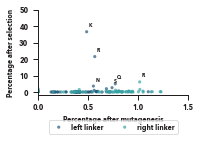

In [15]:
fig, ax = plt.subplots(figsize = (wi3*1.2, hi/4.5))
compared_to = "BC2"
plt.scatter(all_left_linker_perc.loc["BC1",:], all_left_linker_perc.loc[compared_to,:], color = "#22577A", edgecolors='none',alpha=0.7, label = "left linker", s = 10)
plt.scatter(all_right_linker_perc.loc["BC1",:], all_right_linker_perc.loc[compared_to,:], color = "#38A3A5",edgecolors='none', alpha=0.7, label = "right linker", s = 10)

box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])

# Put a legend below current axis
ax.tick_params(axis='y', which='major', pad=5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25),ncol =2)
plt.ylim(0, 50)
ax.set_ylim(-2, 50)  # or -1, depending on how much lift you want

plt.xlim(0, 1.5)
ax.set_xlim(0, 1.5)  # or -0.1 for more space##
ax.set_xticks(np.arange(0, 1.6, 0.5))
plt.xlabel("Percentage after mutagenesis")
plt.ylabel("Percentage after selection")
for i, (x, y) in enumerate(zip(all_left_linker_perc.loc["BC1", :], all_left_linker_perc.loc[compared_to, :])):
    if y > 2:  
        plt.annotate(all_left_linker_perc.columns[i], (x, y), textcoords="offset points", xytext=(2,5), ha='left', fontsize=5)

for i, (x, y) in enumerate(zip(all_right_linker_perc.loc["BC1", :], all_right_linker_perc.loc[compared_to, :])):
    if y > 2:  
        plt.annotate(all_right_linker_perc.columns[i], (x, y), textcoords="offset points", xytext=(2,5), ha='left', fontsize=5)

plt.savefig(f"final_output/Nanopore_P0115/Linker_evolution_scatter_Barcode_13_vs_21.pdf", bbox_inches='tight', dpi = 600)
plt.savefig(f"final_output/Nanopore_P0115/Linker_evolution_scatter_Barcode_13_vs_21.png", bbox_inches='tight')

plt.show()


In [6]:
############# line plots

## filter df for linkers that have a overall occurrence of higher than 1 % 

all_right_linkers = all_right_linkers*100 #calcuate percentages
all_left_linkers = all_left_linkers*100

all_right_linkers = all_right_linkers.loc[:, all_right_linkers.max() > 1]
all_left_linkers = all_left_linkers.loc[:, all_left_linkers.max() > 1]

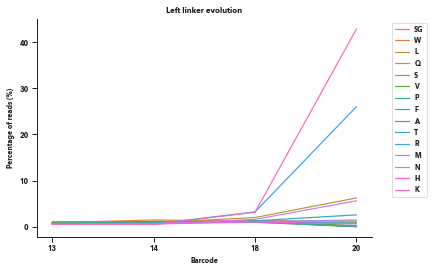

In [7]:

# Number of distinct colors
colors = sns.color_palette("husl", all_left_linkers.shape[1]) 


for i in all_left_linkers.columns:
    plt.plot(all_left_linkers[i], label = i, color = colors[all_left_linkers.columns.get_loc(i)])

## put legend on right side
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Left linker evolution")
plt.xlabel("Barcode")
plt.ylabel("Percentage of reads (%)")
plt.savefig(f"final_output/Nanopore_P0115/left_linker_evolution_barcodes{'_'.join(barcodes)}.png", bbox_inches = "tight")
plt.savefig(f"final_output/Nanopore_P0115/left_linker_evolution_barcodes{'_'.join(barcodes)}.pdf", bbox_inches = "tight")
plt.show()

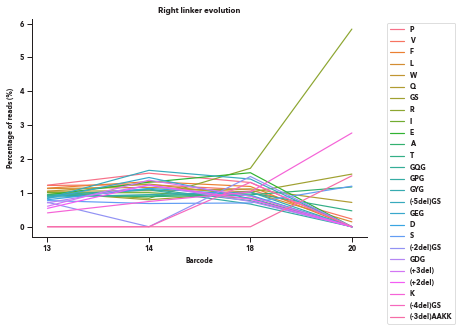

In [8]:
colors = sns.color_palette("husl", all_right_linkers.shape[1]) 

for i in all_right_linkers.columns:
    plt.plot(all_right_linkers[i], label = i, color = colors[all_right_linkers.columns.get_loc(i)],)
plt.title("Right linker evolution")
## put legend on right side
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Barcode")
plt.ylabel("Percentage of reads (%)")
plt.savefig(f"final_output/Nanopore_P0115/right_linker_evolution_barcodes{'_'.join(barcodes)}.png", bbox_inches = "tight")
plt.savefig(f"final_output/Nanopore_P0115/right_linker_evolution_barcodes{'_'.join(barcodes)}.pdf", bbox_inches = "tight")
plt.show()

### Analyze coocurrence

In [3]:
all_cooccs = {}
all_linker_vars = []
barcodes =[13, 14, 15,18, 20]#  [13, 16, 17,19, 21]#[13, 14, 15,18, 20]
barcodes = [str(bc) for bc in barcodes]
for barcode in barcodes: 
    FigFolder = f"final_output/Nanopore_P0115/barcode{barcode}/"
    with open(f"{FigFolder}/cooccurrences.txt", "r") as f:
        cooccurrences = f.read().split("\n")
    cooccs_counts = dict(Counter(cooccurrences))
    
    cooccs_perc = {k: v/sum(cooccs_counts.values())*100 for k, v in cooccs_counts.items()} 
    cooccs_perc_filt = {k: v for k, v in cooccs_perc.items() if v > 0.01}.copy() ## filter out variants with low percentage, likely noise

    # ## normalize filtered cooccs_perc
    cooccs_perc_filt_norm = {k: v/sum(cooccs_perc_filt.values())*100 for k, v in cooccs_perc_filt.items()}

    all_linker_vars = list(set(all_linker_vars+ list(cooccs_perc_filt_norm.keys())))

    all_cooccs[barcode] = cooccs_perc_filt_norm


all_cooccs_df = pd.DataFrame(index = [str(bc) for bc in barcodes], columns = all_linker_vars, data = 0.0)

for barcode in barcodes:
    for linker in all_linker_vars:
        all_cooccs_df.loc[str(barcode), linker] = all_cooccs[barcode].get(linker, 0)


    

In [4]:
variants = {"WT":0, "single mutant": 0, "double mutant": 0}
for key, val in all_cooccs["13"].items(): 
    if key == "wt_wt" or key == "wt_GS" or key == "SG_wt" or key == "SG_GS": 
        variants["WT"] += val

    elif "wt" in key or "GS" in key or "SG" in key: 
        variants["single mutant"] += val
        
    else: 
        variants["double mutant"] += val

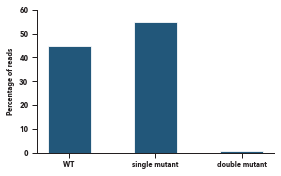

In [5]:
fig = plt.figure(figsize=(wi*0.6, hi/3))

plt.bar(variants.keys(), variants.values(), color = "#22577A", width = 0.5)
plt.ylim(top = 60)
plt.ylabel("Percentage of reads")
plt.savefig("final_output/Nanopore_P0115/WT_single_double_linker_mutants_after_mut_barplot.pdf", bbox_inches = "tight", dpi = 600)
plt.savefig("final_output/Nanopore_P0115/WT_single_double_linker_mutants_after_mut_barplot.pdf", bbox_inches = "tight", dpi = 600)

In [12]:
## sort by size 
all_cooccs["13"] = dict(sorted(all_cooccs["13"].items(), key=lambda item: item[1], reverse = True))
all_cooccs["13"].pop("wt_wt")

43.08175464844357

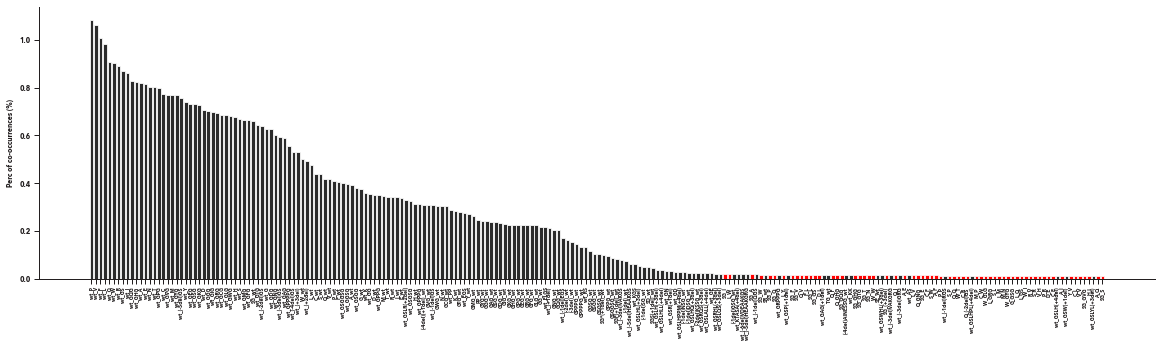

In [13]:
fig, axis = plt.subplots(1,1, figsize = (20, 5))
plt.bar(all_cooccs["13"].keys(), all_cooccs["13"].values())
plt.xticks(rotation=90, fontsize = 5)
##plot bars whose label does not include "wt" in red: 
for i, label in enumerate(all_cooccs["13"].keys()):
    if "wt" not in label:
        plt.bar(i, all_cooccs["13"][label], color = "red")
plt.ylabel("Perc of co-occurrences (%)")
plt.savefig("final_output/Nanopore_P0115/cooccurrence_linkers_barcode13_perc.png", bbox_inches = "tight")
plt.savefig("final_output/Nanopore_P0115/cooccurrence_linkers_barcode13_perc.pdf", bbox_inches = "tight")
plt.show()

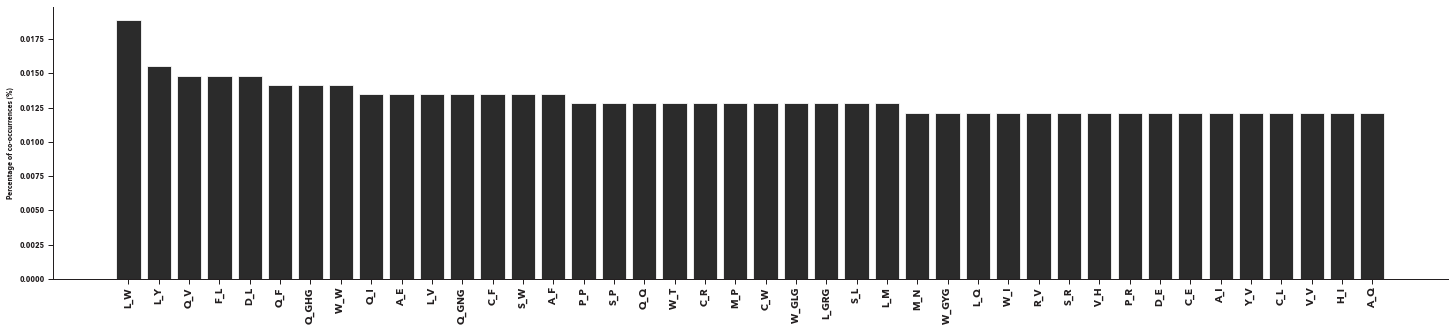

In [14]:
##filter out reads that have wt in the name 
all_cooccs["13"] = {k: v for k, v in all_cooccs["13"].items() if "wt" not in k and "SG" not in k and "GS" not in k}

fig, axis = plt.subplots(1,1, figsize = (25, 5))
plt.bar(all_cooccs["13"].keys(), all_cooccs["13"].values())
plt.xticks(rotation=90, fontsize = 10)
##plot bars whose label does not include "wt" in red: 
plt.ylabel("Percentage of co-occurrences (%)")
plt.savefig("final_output/Nanopore_P0115/cooccurrence_linkers_barcode13_only_coocc_perc.png", bbox_inches = "tight")
plt.savefig("final_output/Nanopore_P0115/cooccurrence_linkers_barcode13_only_coocc_perc.pdf", bbox_inches = "tight")
plt.show()

In [15]:
## filter df for linkers that have a overall occurrence of higher than 1.5 % 
all_cooccs_df = all_cooccs_df.loc[:, all_cooccs_df.max() > 1.5]

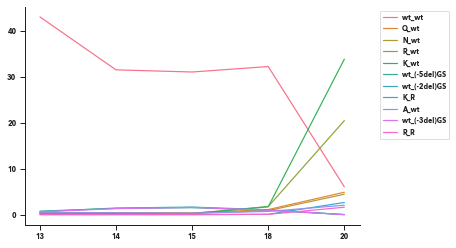

In [16]:
# Number of distinct colors
colors = sns.color_palette("husl", all_cooccs_df.shape[1]) 


for i in all_cooccs_df.columns:
    plt.plot(all_cooccs_df[i], label = i, color = colors[all_cooccs_df.columns.get_loc(i)])
## put legend on right side
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(f"final_output/Nanopore_P0115/cooccurrence_linkers_{'_'.join(barcodes)}.png", bbox_inches = "tight")
plt.savefig(f"final_output/Nanopore_P0115/cooccurrence_linkers_{'_'.join(barcodes)}.pdf", bbox_inches = "tight")

plt.show()